# Visual RAG: CLIP + ChromaDB + Qwen3-VL

이 노트북은 **Visual RAG(Retrieval-Augmented Generation)** 파이프라인을 단계별로 구현합니다.

## 전체 흐름

```
COCO 이미지 100장
       ↓
    CLIP (OpenCLIP)
       ↓
   Embedding
       ↓
   ChromaDB
       ↓
 Query Embedding (텍스트)
       ↓
   Top-k Search
       ↓
 Qwen3-VL (검색된 이미지 전달)
       ↓
  이미지 내용 요약
       ↓
 "이 사진들의 공통점은?"
```

| 단계 | 역할 |
|------|------|
| **CLIP** | 이미지·텍스트를 같은 벡터 공간에 매핑 (검색용) |
| **ChromaDB** | 임베딩 저장 및 유사도 Top-k 검색 |
| **Qwen3-VL** | 검색된 이미지를 이해하고 요약·공통점 분석 (생성용) |

### Visual RAG란?

- **RAG(Retrieval-Augmented Generation)**: 검색으로 관련 정보를 먼저 찾고, 그 결과를 LLM에 넣어 답을 생성하는 방식입니다.
- **Visual RAG**: 텍스트 대신 **이미지**를 검색하는 RAG입니다. "고양이 사진 찾아줘" 같은 질의에 맞는 이미지를 찾은 뒤, VLM(시각-언어 모델)이 내용을 설명합니다.
- 이 노트북은 **검색(Retriever)** 과 **생성(Generator)** 을 분리합니다. 검색은 가볍고 빠르게, 생성은 정밀하게 처리합니다.


## 0. 환경 설정


In [ ]:
# !py -3.11 -m pip install -r requirements.txt
# [설명] Windows에서 Python 3.11 지정 설치 예시. 터미널에서도 동일하게 실행 가능합니다.

# pip install -r requirements.txt
# [설명] 현재 Jupyter 커널의 Python에 패키지를 설치합니다.


In [ ]:
# 설치후 재시작 필요
# py -3.11 -m pip install pycocotools
# [설명] COCO 어노테이션 파싱에 필요한 pycocotools 단독 설치 명령입니다.


In [ ]:
# import sys
# import subprocess

# def pip_install(*packages):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])

# try:
#     import pycocotools  # noqa: F401
# except ModuleNotFoundError:
#     print(f"Installing pycocotools into: {sys.executable}")
#     pip_install("pycocotools>=2.0.7")
#     import pycocotools  # noqa: F401

# print("pycocotools OK")
# [설명] 커널 Python 경로(sys.executable)에 맞춰 pycocotools를 설치하는 대안 코드입니다.
# Jupyter 커널과 터미널 pip 버전이 다를 때 유용합니다.


In [ ]:
# !pip install chromadb qwen-vl-utils accelerate pycocotools open-clip-torch

requirements.txt 을 만들어 설치한다
```
torch>=2.1.0
torchvision>=0.16.0
transformers>=4.57.0
accelerate>=0.27.0
chromadb>=0.5.0
open-clip-torch>=2.24.0
pillow>=10.0.0
matplotlib>=3.8.0
tqdm>=4.66.0
pycocotools>=2.0.7
qwen-vl-utils>=0.0.8
jupyter>=1.0.0
ipywidgets>=8.0.0
```

### 패키지 한 줄 설명

| 패키지 | 용도 |
|--------|------|
| `torch` | 딥러닝 연산 (GPU 사용) |
| `transformers` | Qwen3-VL, SigLIP2 등 Hugging Face 모델 로드 |
| `chromadb` | 벡터 DB — 임베딩 저장·유사도 검색 |
| `open-clip-torch` | OpenCLIP 모델 (ChromaDB가 내부적으로 사용) |
| `pycocotools` | COCO 데이터셋 어노테이션 파싱 |
| `Pillow` | 이미지 파일 읽기/쓰기 |
| `matplotlib` | 검색 결과·샘플 이미지 시각화 |
| `tqdm` | 다운로드·인덱싱 진행률 표시 |


In [ ]:
# =============================================================================
# 환경 설정: 라이브러리 import, 한글 폰트, 경로·하이퍼파라미터 정의
# =============================================================================

# --- 표준 라이브러리 ---
import os              # 파일 시스템, 환경 변수
import json              # JSON 직렬화 (필요 시 메타데이터 저장)
import random            # 이미지 ID 무작위 섞기 (재현 가능한 샘플링)
import urllib.request    # COCO 어노테이션·이미지 HTTP 다운로드
import zipfile           # annotations zip 압축 해제
import platform          # Windows / Linux / macOS 판별 (폰트 설정용)
import subprocess        # Colab에서 fonts-nanum 설치 시 사용
from pathlib import Path # OS에 맞는 경로 처리 (Windows \ vs Linux /)

# --- 딥러닝·시각화 ---
import torch             # PyTorch — GPU 텐서 연산, CUDA 사용
import matplotlib.pyplot as plt       # 그래프·이미지 그리드 시각화
import matplotlib.font_manager as fm  # 시스템 폰트 목록 조회·등록
from PIL import Image    # 이미지 파일 로드 (Qwen3-VL, SigLIP2 입력)
from tqdm.auto import tqdm  # for 루프 진행률 바 표시


def setup_korean_matplotlib():
    """Windows / Google Colab / macOS에서 matplotlib 한글 폰트 설정."""
    global _MATPLOTLIB_KO_READY
    if _MATPLOTLIB_KO_READY:
        return plt.rcParams.get("font.family")

    system = platform.system()

    def font_names():
        # 시스템에 설치된 모든 TTF/OTF 폰트 이름 집합
        return {f.name for f in fm.fontManager.ttflist}

    chosen = None

    if system == "Windows":
        # 맑은 고딕(Malgun Gothic)이 Windows 기본 한글 폰트
        for name in ("Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"):
            if name in font_names():
                chosen = name
                break
    elif system == "Darwin":
        # macOS 한글 폰트 후보
        for name in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic"):
            if name in font_names():
                chosen = name
                break
    else:
        # Linux / Google Colab
        nanum_paths = [
            "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
            "/usr/share/fonts/nanum/NanumGothic.ttf",
        ]
        if not any(os.path.exists(p) for p in nanum_paths):
            try:
                # Colab: 나눔폰트 패키지 설치 (최초 1회, 수십 초 소요 가능)
                subprocess.run(
                    ["apt-get", "-qq", "install", "-y", "fonts-nanum"],
                    check=False,
                    stdout=subprocess.DEVNULL,
                    stderr=subprocess.DEVNULL,
                )
            except Exception:
                pass

        for path in nanum_paths:
            if os.path.exists(path):
                fm.fontManager.addfont(path)
                chosen = fm.FontProperties(fname=path).get_name()
                break

        if chosen is None:
            for name in ("NanumGothic", "NanumBarunGothic", "UnDotum"):
                if name in font_names():
                    chosen = name
                    break

    if chosen:
        plt.rcParams["font.family"] = chosen
    else:
        print("경고: 한글 폰트를 찾지 못했습니다. 제목 한글이 깨질 수 있습니다.")

    # 유니코드 마이너스(−) 대신 ASCII 하이픈(-) 사용 → 음수 축 레이블 깨짐 방지
    plt.rcParams["axes.unicode_minus"] = False
    _MATPLOTLIB_KO_READY = True
    return chosen


_MATPLOTLIB_KO_READY = False  # 폰트 설정 1회만 수행하는 플래그

# 재현성
SEED = 42
random.seed(SEED)       # Python random 모듈 시드 고정
torch.manual_seed(SEED) # PyTorch 시드 고정 (일부 연산만 결정적)

# matplotlib 한글 폰트 (시각화 셀 실행 전 1회 설정)
_korean_font = setup_korean_matplotlib()
print(f"matplotlib 한글 폰트: {_korean_font or '미설정'}")

# --- 데이터·DB 경로 설정 ---
ROOT = Path(".")                              # 노트북 실행 위치(프로젝트 루트)
DATA_DIR = ROOT / "data"                      # 모든 데이터 하위 폴더의 부모
COCO_IMG_DIR = DATA_DIR / "coco_images"       # 다운로드한 COCO 이미지 저장
COCO_ANN_DIR = DATA_DIR / "coco_annotations"  # COCO JSON 어노테이션 저장
CHROMA_DIR = DATA_DIR / "chroma_db"           # ChromaDB 영구 저장 경로

for d in [DATA_DIR, COCO_IMG_DIR, COCO_ANN_DIR, CHROMA_DIR]:
    d.mkdir(parents=True, exist_ok=True)  # exist_ok=True: 이미 있으면 무시

# --- 파이프라인 하이퍼파라미터 ---
NUM_IMAGES = 100                  # 사용할 COCO 이미지 수 (실습용으로 100장)
TOP_K = 5                         # 검색 시 반환할 상위 이미지 개수
COLLECTION_NAME = "coco_clip_100" # OpenCLIP용 ChromaDB 컬렉션 이름

# GPU 사용 가능 시 cuda, 아니면 cpu (Qwen3-VL·SigLIP2 속도에 큰 영향)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")


matplotlib 한글 폰트: NanumGothic
Device: cuda
PyTorch: 2.11.0+cu128


## 1. COCO 이미지 100장 준비

COCO 2017 **validation** 어노테이션에서 이미지 ID 100개를 선택하고, 해당 이미지를 다운로드합니다.

> 첫 실행 시 어노테이션 zip(~250MB)과 이미지 100장을 다운로드합니다. 이미 받은 파일은 건너뜁니다.


| 기술 | 설명 |
|------|------|
| **COCO** | Common Objects in Context — 사물 인식 연구용 대규모 이미지 데이터셋 |
| **pycocotools** | COCO의 JSON 어노테이션(라벨, bbox 등)을 읽는 공식 도구 |
| **urllib** | 이미지 URL에서 파일을 로컬로 다운로드 |

**왜 100장만?** 전체 파이프라인을 빠르게 실습하기 위함입니다. 실제 서비스에서는 수천~수만 장을 인덱싱합니다.


In [ ]:
# COCO 2017 instances_val2017.json 어노테이션 다운로드·압축 해제
# 이미지 본체는 포함되지 않으며, 라벨·URL 정보만 담긴 JSON입니다.

ANN_ZIP = DATA_DIR / "annotations_trainval2017.zip"
ANN_FILE = COCO_ANN_DIR / "annotations" / "instances_val2017.json"

if not ANN_FILE.exists():
    if not ANN_ZIP.exists():
        print("COCO annotations 다운로드 중...")
        # 공식 COCO 서버에서 train+val 어노테이션 zip 받기 (~250MB)
        urllib.request.urlretrieve(
            "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
            ANN_ZIP,
        )
    print("어노테이션 압축 해제 중...")
    with zipfile.ZipFile(ANN_ZIP, "r") as zf:
        zf.extractall(COCO_ANN_DIR)
    print("완료.")
else:
    print("어노테이션 이미 존재 — 건너뜀.")


어노테이션 이미 존재 — 건너뜀.


In [ ]:
# pycocotools: COCO API — 이미지 ID, 카테고리, bbox 등 조회
from pycocotools.coco import COCO

coco = COCO(str(ANN_FILE))
all_img_ids = coco.getImgIds()       # val2017 전체 이미지 ID 목록
random.shuffle(all_img_ids)          # 무작위 섞기 (SEED 고정으로 재현 가능)
selected_ids = all_img_ids[:NUM_IMAGES]  # 상위 NUM_IMAGES개 선택

print(f"전체 val 이미지: {len(all_img_ids):,}장")
print(f"선택된 이미지: {len(selected_ids)}장")

# 메타데이터 수집
image_records = []  # 이후 ChromaDB·SigLIP2 인덱싱에 사용할 딕셔너리 리스트
for img_id in selected_ids:
    info = coco.loadImgs(img_id)[0]           # file_name, width, height, coco_url 등
    ann_ids = coco.getAnnIds(imgIds=img_id)   # 해당 이미지의 객체 어노테이션 ID
    anns = coco.loadAnns(ann_ids)
    # category_id → 영어 클래스명(person, car 등)으로 변환 후 중복 제거·정렬
    labels = sorted({coco.loadCats(a["category_id"])[0]["name"] for a in anns})
    image_records.append({
        "id": str(img_id),                    # ChromaDB 문서 ID (문자열)
        "file_name": info["file_name"],
        "coco_url": info.get("coco_url", f"http://images.cocodataset.org/val2017/{info['file_name']}"),
        "width": info["width"],
        "height": info["height"],
        "labels": labels,
    })

image_records[:3]  # Jupyter: 앞 3개 레코드 미리보기


loading annotations into memory...
Done (t=0.51s)
creating index...
index created!
전체 val 이미지: 5,000장
선택된 이미지: 100장


[{'id': '21465',
  'file_name': '000000021465.jpg',
  'coco_url': 'http://images.cocodataset.org/val2017/000000021465.jpg',
  'width': 500,
  'height': 281,
  'labels': ['chair', 'vase']},
 {'id': '563281',
  'file_name': '000000563281.jpg',
  'coco_url': 'http://images.cocodataset.org/val2017/000000563281.jpg',
  'width': 489,
  'height': 500,
  'labels': ['person', 'toothbrush']},
 {'id': '447187',
  'file_name': '000000447187.jpg',
  'coco_url': 'http://images.cocodataset.org/val2017/000000447187.jpg',
  'width': 640,
  'height': 480,
  'labels': ['baseball bat', 'baseball glove', 'person', 'sports ball']}]

이미지 다운로드:   0%|          | 0/100 [00:00<?, ?it/s]

로컬 이미지: 100장


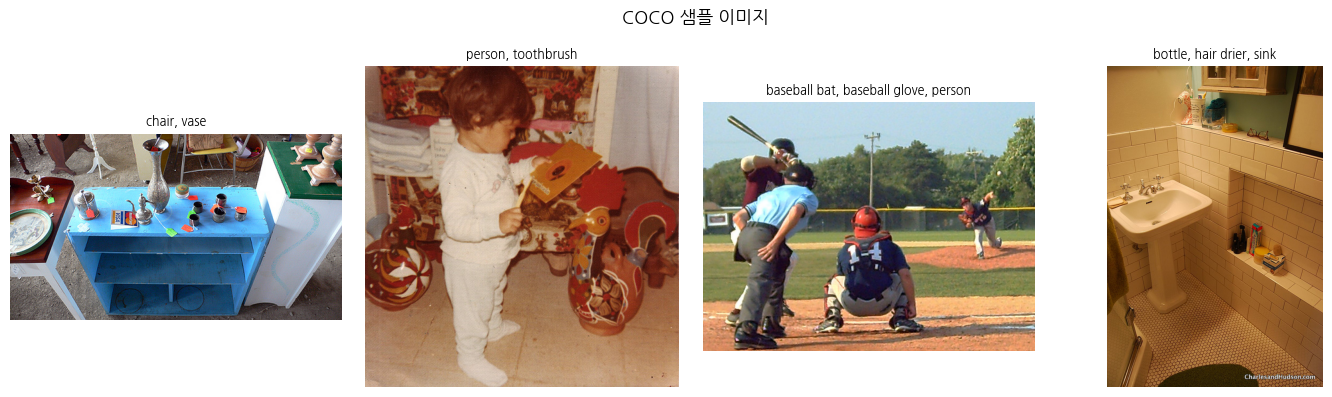

In [ ]:
def download_coco_images(records, save_dir: Path):
    """COCO URL에서 이미지를 로컬로 다운로드. 이미 있으면 건너뜀."""
    save_dir.mkdir(parents=True, exist_ok=True)
    downloaded = []
    for rec in tqdm(records, desc="이미지 다운로드"):
        dst = save_dir / rec["file_name"]
        if not dst.exists():
            try:
                urllib.request.urlretrieve(rec["coco_url"], dst)
            except Exception as e:
                print(f"실패: {rec['file_name']} — {e}")
                continue
        rec["local_path"] = str(dst.resolve())  # 절대 경로 — ChromaDB uri·Qwen 입력에 사용
        downloaded.append(rec)
    return downloaded

image_records = download_coco_images(image_records, COCO_IMG_DIR)
print(f"로컬 이미지: {len(image_records)}장")

# 샘플 미리보기
setup_korean_matplotlib()  # 한글 제목 "COCO 샘플 이미지" 깨짐 방지
fig, axes = plt.subplots(1, 4, figsize=(14, 4))  # 1행 4열 서브플롯
for ax, rec in zip(axes, image_records[:4]):
    ax.imshow(Image.open(rec["local_path"]))
    ax.set_title(", ".join(rec["labels"][:3]) or "(no label)", fontsize=9)
    ax.axis("off")  # 축 눈금 숨김
plt.suptitle("COCO 샘플 이미지", fontsize=13)
plt.tight_layout()
plt.show()

# PC 약 2분 소요


## 2. CLIP 임베딩 → ChromaDB 저장

ChromaDB의 `OpenCLIPEmbeddingFunction`이 **OpenCLIP** 모델로 이미지를 자동 임베딩합니다.
이미지 URI만 저장하면 Chroma가 로드·임베딩·인덱싱을 처리합니다.

### 이 단계에서 쓰는 기술

| 기술 | 설명 |
|------|------|
| **CLIP / OpenCLIP** | 이미지와 텍스트를 **같은 벡터 공간**에 넣는 모델. "dog"이라는 글자와 개 사진이 비슷한 벡터가 됩니다. |
| **Embedding(임베딩)** | 이미지·텍스트를 숫자 벡터(예: 512차원)로 변환한 것. 유사한 의미일수록 벡터가 가깝습니다. |
| **ChromaDB** | 벡터를 저장하고 **코사인 유사도**로 빠르게 검색하는 DB |
| **HNSW** | ChromaDB 내부의 근사 최근접 탐색 알고리즘 (`hnsw:space: cosine`) |

<br>

> OpenCLIP은 **영어** 쿼리에 강합니다. 한글 검색은 뒤쪽 SigLIP2 섹션을 참고하세요.


In [ ]:
import chromadb
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader

# CLIP (OpenCLIP) 임베딩 함수
# ViT-B-32: Vision Transformer Base, 32x32 패치 — 속도·품질 균형 모델
# laion2b_s34b_b79k: LAION-2B 데이터로 학습된 체크포인트
clip_ef = OpenCLIPEmbeddingFunction(
    model_name="ViT-B-32",
    checkpoint="laion2b_s34b_b79k",
)
# ImageLoader: collection.add(uris=...) 시 로컬 파일 경로에서 이미지를 읽어옴
image_loader = ImageLoader()

# PersistentClient: 디스크에 DB 저장 (재실행해도 인덱스 유지)
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# 기존 컬렉션 삭제 후 재생성 (재실행 시 깨끗한 상태)
try:
    chroma_client.delete_collection(COLLECTION_NAME)
except Exception:
    pass  # 최초 실행 시 컬렉션이 없으면 예외 — 무시

collection = chroma_client.create_collection(
    name=COLLECTION_NAME,
    embedding_function=clip_ef,   # add/query 시 자동으로 OpenCLIP 임베딩
    data_loader=image_loader,
    metadata={"hnsw:space": "cosine"},  # 코사인 거리 기반 근사 최근접 검색
)


def get_clip_collection():
    """디스크에서 OpenCLIP 컬렉션을 이름으로 다시 로드 (stale UUID 방지)."""
    return chroma_client.get_collection(
        name=COLLECTION_NAME,
        embedding_function=clip_ef,
        data_loader=image_loader,
    )


print(f"컬렉션 생성: {COLLECTION_NAME}")

# 다운로드 : 약 2분 소요

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

컬렉션 생성: coco_clip_100


In [ ]:
BATCH_SIZE = 50  # 한 번에 add할 이미지 수 (메모리·속도 트레이드오프)

for i in tqdm(range(0, len(image_records), BATCH_SIZE), desc="ChromaDB 인덱싱"):
    batch = image_records[i : i + BATCH_SIZE]
    collection.add(
        ids=[r["id"] for r in batch],              # 고유 ID
        uris=[r["local_path"] for r in batch],     # 이미지 경로 → OpenCLIP이 자동 임베딩
        metadatas=[                                # 검색 결과 표시·필터용 부가 정보
            {
                "file_name": r["file_name"],
                "labels": ", ".join(r["labels"]),  # COCO 영어 라벨
                "width": r["width"],
                "height": r["height"],
            }
            for r in batch
        ],
    )

print(f"인덱싱 완료: {collection.count()}개 벡터")

# RTX 3060 : 약 1.5분 소요


ChromaDB 인덱싱:   0%|          | 0/2 [00:00<?, ?it/s]

인덱싱 완료: 100개 벡터


## 3. Query Embedding → Top-k Search

자연어 쿼리를 CLIP 텍스트 인코더로 임베딩하고, ChromaDB에서 코사인 유사도 기준 **Top-k** 이미지를 검색합니다.

### 이 단계에서 쓰는 기술

| 기술 | 설명 |
|------|------|
| **Query Embedding** | 사용자가 입력한 문장을 CLIP 텍스트 인코더로 벡터화 |
| **Top-k Search** | DB에서 쿼리 벡터와 가장 가까운 이미지 **k개**(기본 5개)를 반환 |
| **Cosine Similarity** | 두 벡터 방향이 얼마나 비슷한지 측정 (1에 가까울수록 유사) |

검색 결과의 `distance`는 ChromaDB의 코사인 **거리**이며, 코드에서 `similarity = 1 - distance`로 변환해 표시합니다.


In [ ]:
def search_images(query: str, top_k: int = TOP_K):
    """텍스트 쿼리 → CLIP query embedding → ChromaDB Top-k 검색"""
    col = get_clip_collection()
    if col.count() == 0:
        raise RuntimeError(
            f"'{COLLECTION_NAME}' 컬렉션이 비어 있습니다. "
            "섹션 2 ChromaDB 인덱싱 셀을 다시 실행하세요."
        )
    results = col.query(
        query_texts=[query],   # CLIP 텍스트 인코더가 쿼리를 벡터화
        n_results=top_k,
        include=["uris", "metadatas", "distances"],  # 반환 필드 지정
    )
    hits = []
    for j in range(len(results["ids"][0])):
        hits.append({
            "rank": j + 1,
            "id": results["ids"][0][j],
            "uri": results["uris"][0][j],           # 로컬 이미지 절대 경로
            "distance": results["distances"][0][j], # 코사인 거리 (0에 가까울수록 유사)
            "similarity": 1 - results["distances"][0][j],
            "metadata": results["metadatas"][0][j],
        })
    return hits


def show_search_results(query: str, hits: list):
    """검색된 Top-k 이미지를 한 줄로 시각화하고 콘솔에 라벨 출력"""
    setup_korean_matplotlib()
    n = len(hits)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.5))
    if n == 1:
        axes = [axes]  # subplot 1개일 때 axes가 Axes 객체 하나이므로 리스트로 통일
    for ax, hit in zip(axes, hits):
        img = Image.open(hit["uri"])
        ax.imshow(img)
        title = hit["metadata"].get("labels", "")[:40]
        ax.set_title(f"#{hit['rank']} sim={hit['similarity']:.3f}\n{title}", fontsize=8)
        ax.axis("off")
    plt.suptitle(f'Query: "{query}"', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    print()
    print("검색 결과:")
    for h in hits:
        print(f"  [{h['rank']}] id={h['id']}  similarity={h['similarity']:.4f}  labels={h['metadata'].get('labels', '')}")


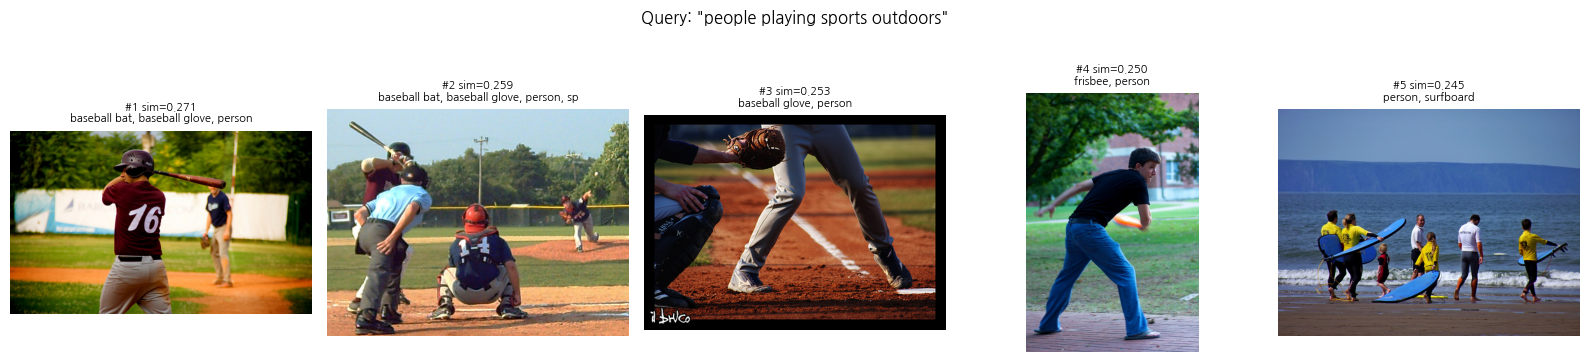


검색 결과:
  [1] id=356094  similarity=0.2712  labels=baseball bat, baseball glove, person
  [2] id=447187  similarity=0.2588  labels=baseball bat, baseball glove, person, sports ball
  [3] id=512776  similarity=0.2527  labels=baseball glove, person
  [4] id=343803  similarity=0.2495  labels=frisbee, person
  [5] id=326174  similarity=0.2452  labels=person, surfboard


In [ ]:
# 검색 쿼리 — 원하는 문장으로 바꿔 보세요
# OpenCLIP은 영어 쿼리에 최적화되어 있습니다.
QUERY = "people playing sports outdoors"

hits = search_images(QUERY, top_k=TOP_K)
show_search_results(QUERY, hits)


## 4. Qwen3-VL — 검색 이미지 요약 및 공통점 분석

검색된 Top-k 이미지를 **Qwen3-VL**에 전달하여:
1. 각 이미지 내용 요약
2. "이 사진들의 공통점은?" 질의에 답변

> GPU VRAM 8GB 이상 권장. 메모리가 부족하면 `QWEN_MODEL`을 더 작은 모델로 변경하세요.

### 이 단계에서 쓰는 기술

| 기술 | 설명 |
|------|------|
| **Qwen3-VL** | Alibaba의 시각-언어 모델(VLM). 이미지를 보고 한국어로 설명·분석 가능 |
| **VLM (Vision-Language Model)** | 이미지 + 텍스트를 함께 이해하는 멀티모달 AI |
| **Retrieval vs Generation** | CLIP/SigLIP2는 **찾기**, Qwen3-VL은 **이해·생성** 담당 |

Qwen3-VL은 VRAM을 많이 씁니다. 그래서 검색으로 **소수(Top-k) 이미지만** 넘기는 것이 Visual RAG의 핵심입니다.


In [ ]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

# GPU 메모리에 맞게 모델 선택
# - 4B: ~8GB VRAM  /  2B: ~4GB VRAM  /  8B: ~16GB VRAM
QWEN_MODEL = "Qwen/Qwen3-VL-4B-Instruct"

print(f"Qwen3-VL 로딩: {QWEN_MODEL}")
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL,
    torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,  # GPU: bfloat16 절약
    device_map="auto" if device == "cuda" else None,  # GPU 자동 배치
    attn_implementation="sdpa",  # Scaled Dot-Product Attention (메모리 효율)
)
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL)  # 이미지·텍스트 전처리·토크나이저
print("로딩 완료.")


Qwen3-VL 로딩: Qwen/Qwen3-VL-4B-Instruct


config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/64.7k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

로딩 완료.


In [ ]:
def run_qwen_vl(image_paths: list[str], prompt: str, max_new_tokens: int = 128) -> str:
    """여러 이미지 + 텍스트 프롬프트로 Qwen3-VL 추론"""
    # Windows: file:// 경로 대신 PIL Image 객체로 전달 (호환성)
    content = [{"type": "image", "image": Image.open(p).convert("RGB")} for p in image_paths]
    content.append({"type": "text", "text": prompt})

    messages = [{"role": "user", "content": content}]

    # 채팅 템플릿 적용 → 모델 입력 토큰 텐서 생성
    inputs = qwen_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,  # assistant 응답 시작 토큰 추가
        return_dict=True,
        return_tensors="pt",
    )
    inputs = inputs.to(qwen_model.device)

    with torch.no_grad():  # 추론 시 gradient 계산 비활성 (메모리·속도)
        generated_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            repetition_penalty=1.15,  # 같은 단어 반복 억제
            do_sample=False,          # greedy decoding (결정적 출력)
        )

    # 입력 토큰 부분 제거 → 새로 생성된 토큰만 디코딩
    trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    return qwen_processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()


def summarize_images(image_paths: list[str]) -> str:
    """이미지를 한 장씩 요약해 반복 생성(repetition)을 방지"""
    single_prompt = (
        "이 사진에서 보이는 주요 대상, 행동, 장소를 한 문장(60자 이내)으로 "
        "한국어로 설명하세요. 같은 단어를 반복하지 마세요."
    )
    lines_out = []
    for i, path in enumerate(image_paths, 1):
        summary = run_qwen_vl([path], single_prompt, max_new_tokens=80)
        lines_out.append(f"이미지 {i}: {summary}")
        print(f"  이미지 {i}/{len(image_paths)} 요약 완료")
    return "\n".join(lines_out)


def analyze_commonality(image_paths: list[str], summaries: str) -> str:
    """개별 요약을 참고해 공통점 분석"""
    prompt = (
        f"아래 {len(image_paths)}장의 이미지와 요약을 함께 보고, "
        "이 사진들의 공통점을 3~5문장으로 한국어로 설명하세요. "
        "같은 단어를 반복하지 마세요.\n\n"
        f"[개별 요약]\n{summaries}"
    )
    return run_qwen_vl(image_paths, prompt, max_new_tokens=200)


# 직전 검색(섹션 3) 결과 이미지 경로 — Step A/B에서 사용
retrieved_paths = [h["uri"] for h in hits]
print(f"Qwen3-VL에 전달할 이미지: {len(retrieved_paths)}장")


Qwen3-VL에 전달할 이미지: 5장


In [ ]:
# Step A: 이미지 내용 요약 (한 장씩 처리)
# 여러 장을 한 번에 넣으면 토큰 반복·환각이 발생할 수 있어 1장씩 요약합니다.
print("=" * 60)
print("[Step A] 이미지 내용 요약")
print("=" * 60)
summaries = summarize_images(retrieved_paths)
print(summaries)


[Step A] 이미지 내용 요약
  이미지 1/5 요약 완료
  이미지 2/5 요약 완료
  이미지 3/5 요약 완료
  이미지 4/5 요약 완료
  이미지 5/5 요약 완료
이미지 1: 야구장에서 타격을 준비하는 선수와 투수의 모습입니다.
이미지 2: 야구장에서 타격을 시도하는 선수와 캐치어, 투수의 활동 모습입니다.
이미지 3: 야구장에서 캐치어와 타격수의 경기 순간을 포착한 이미지입니다.
이미지 4: 남자가 공원에서 파란 청바지와 검은 티셔츠를 입고 오렌지색 프리스케이트를 던지고 있다.
이미지 5: 해변에서 수영복을 입은 사람들이 파도에 맞서는 자세로 서 있습니다.


In [ ]:
# Step B: 공통점 분석
# Step A에서 만든 텍스트 요약 + 원본 이미지를 함께 Qwen3-VL에 전달합니다.
print("=" * 60)
print('[Step B] "이 사진들의 공통점은?"')
print("=" * 60)
common_answer = analyze_commonality(retrieved_paths, summaries)
print(common_answer)


[Step B] "이 사진들의 공통점은?"
이 세 가지 이미지는 모두 외부 공간에서 진행되는 운동 장면을 담고 있으며, 각각 다른 스포츠나 놀이를 표현합니다. 야구장에서는 타자와 캐치어가 협력하여 게임을 즐기는 모습이 강조되며, 해변에서는 수상 스포츠인 서핑을 위한 준비가 이루어지고 있습니다. 마지막 이미지는 공원에서 자유롭게 플레이하는 프리스케이트를 통해 여유로운 시간을 보내는 모습을 보여줍니다. 모든 장면은 자연 환경과 인간의 활동이 조화를 이루는 생생한 일상을 기록하고 있습니다.


## 5. Visual RAG 파이프라인 통합

검색 → 요약 → 공통점 분석을 한 함수로 묶었습니다.

### 이 단계에서 쓰는 기술

`visual_rag()` 함수 하나로 **검색 → 요약 → 공통점 분석**을 순서대로 실행합니다.

- 영어 쿼리: OpenCLIP 검색 경로 사용
- 한글 쿼리: 아래 SigLIP2 기반 `visual_rag_siglip2()` 사용 권장



🔍 Query: a cat sitting indoors
--------------------------------------------------


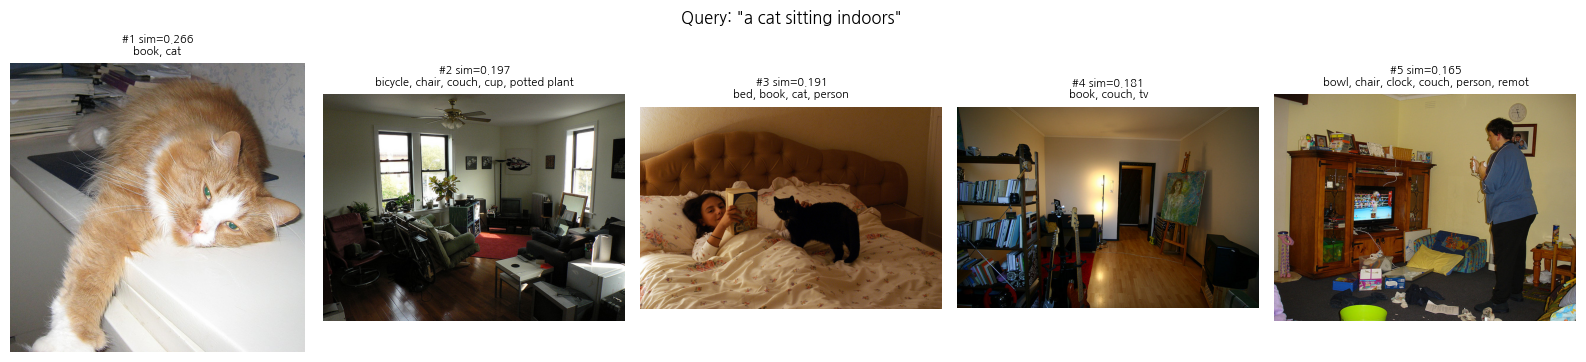


검색 결과:
  [1] id=58111  similarity=0.2657  labels=book, cat
  [2] id=36844  similarity=0.1967  labels=bicycle, chair, couch, cup, potted plant, refrigerator, remote, tv
  [3] id=458255  similarity=0.1910  labels=bed, book, cat, person
  [4] id=104666  similarity=0.1808  labels=book, couch, tv
  [5] id=195842  similarity=0.1647  labels=bowl, chair, clock, couch, person, remote, tv
  이미지 1/5 요약 완료
  이미지 2/5 요약 완료
  이미지 3/5 요약 완료
  이미지 4/5 요약 완료
  이미지 5/5 요약 완료

📝 이미지 요약:
이미지 1: 금발 흰 코의 고양이가 책상 위에 누워 눈을 뜨고 있다.
이미지 2: living room에 가구와 식물들이 배치된 편안한 공간입니다.
이미지 3: 침대에 누워서 책을 읽는 소녀와 검은 고양이가 함께 있는 모습.
이미지 4: living room에 기타와 그림, TV가 있는 따뜻한 분위기의 공간입니다.
이미지 5: 客厅에서 게임을 즐기는 여성이 있는 모습입니다.

🔗 공통점:
이 세 가지 장면은 모두 실내 환경을 중심으로 구성되어 있으며, 각각 다른 인물이나 동물이 평온하거나 활동적인 순간을 보내고 있습니다. 첫 번째 이미지는 고양이가 책상 위에 편안하게 누워 있는 모습을 담았으며, 나머지 이미지들은 인간이 주도하는 생활 공간—客厅과 침실—에서 일상의 다양한 순간들을 포착하고 있습니다. 특히, 두 번째와 네 번째 이미지는 거실이라는 공용 공간을 강조하며, 가구나 예술 작품 등이 조화롭게 배치된 아늑함을 전달합니다. 마지막 이미지는 게임을 즐기는 사람의 활동을 보여주며, 전체적으로 집 안에서의 편안함과 삶의 질을 드러

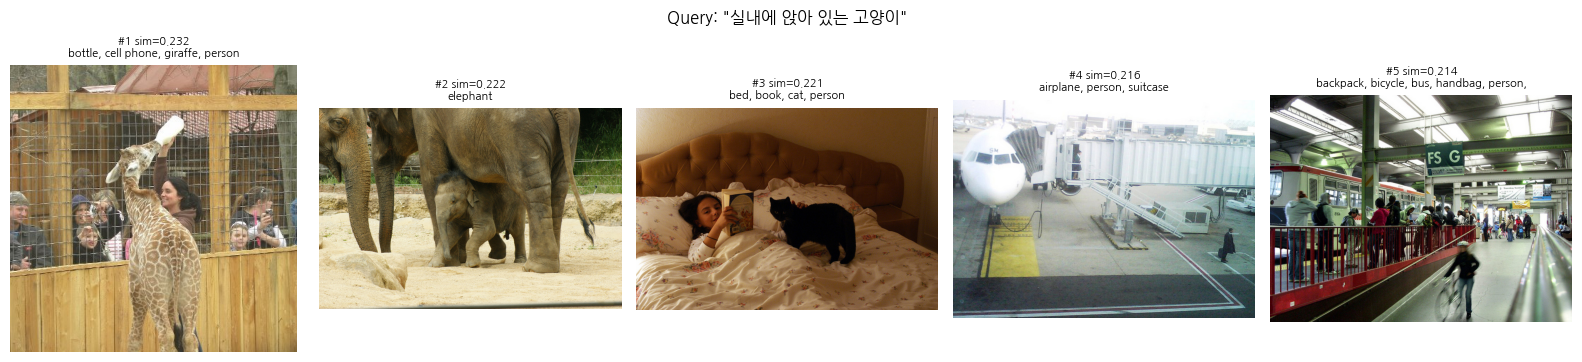


검색 결과:
  [1] id=302452  similarity=0.2320  labels=bottle, cell phone, giraffe, person
  [2] id=110638  similarity=0.2218  labels=elephant
  [3] id=458255  similarity=0.2206  labels=bed, book, cat, person
  [4] id=348881  similarity=0.2160  labels=airplane, person, suitcase
  [5] id=350122  similarity=0.2136  labels=backpack, bicycle, bus, handbag, person, train
  이미지 1/5 요약 완료
  이미지 2/5 요약 완료
  이미지 3/5 요약 완료
  이미지 4/5 요약 완료
  이미지 5/5 요약 완료

📝 이미지 요약:
이미지 1: 조류가 사람과 함께 먹이를 받으며 관람객들이 뒤에 서 있다.
이미지 2: 큰 여우와 아기 여우가 흙바닥에 서 있는 동물원의 모습입니다.
이미지 3: 침대에 누워서 책을 읽는 소녀와 검은 고양이가 함께 있는 모습.
이미지 4: 공항 터미널에서 비행기와 객차 연결 중인 모습입니다.
이미지 5: 지하철역에서 사람들이 기다리고, 자전거 타는 사람도 보입니다.

🔗 공통점:
이 세 가지 장면은 모두 인간이 자연 또는 인공 환경 속에서 활동하는 상황을 담고 있습니다. 첫 번째 이미지는 동물원에서 사람과 동물이 직접적으로 상호작용하는 따뜻한 순간을, 두 번째는 동물의 생활 공간을 보여주는 자연주의적 분위기를, 세 번째는 가정 내 개인적인 시간을 포착한 평화로운 장면을 각각 담고 있습니다. 네 번째와 다섯 번째 이미지는 대규모 인프라에서 일어나는 교통 관련 활동을 보여주며, 도시생활의 일부를 전달합니다. 전체적으로는 인간 중심의 다양한 삶의 순간들을 담은 캡처입니다.


In [ ]:
def visual_rag(query: str, top_k: int = TOP_K, show_images: bool = True):
    """
    Visual RAG end-to-end:
      Query → CLIP Embedding → ChromaDB Top-k → Qwen3-VL 요약·공통점
    """
    print()
    print(f"🔍 Query: {query}")
    print("-" * 50)

    # 1) Retrieval — OpenCLIP + ChromaDB로 관련 이미지 검색
    hits = search_images(query, top_k=top_k)
    if show_images:
        show_search_results(query, hits)

    paths = [h["uri"] for h in hits]

    # 2) Generation — 요약
    summary = summarize_images(paths)
    print()
    print("📝 이미지 요약:")
    print(summary)

    # 3) Generation — 공통점
    common = analyze_commonality(paths, summary)
    print()
    print("🔗 공통점:")
    print(common)

    return {"hits": hits, "summary": summary, "common": common}


# 다른 쿼리로 실험해 보세요
result = visual_rag("a cat sitting indoors", top_k=5) # 영문은 정상 동작
result = visual_rag("실내에 앉아 있는 고양이", top_k=5) # 한글은 성능 낮음!!

# RTX 3060 : 약 5분 소요

## 6. SigLIP2 So400M — 한글 쿼리 검색 개선

OpenCLIP은 **영어 중심** 학습이라 한글 쿼리 검색 성능이 낮습니다.

**SigLIP2 So400M** (`google/siglip2-so400m-patch14-384`)은 다국어(한글 포함) 텍스트–이미지 정렬이 강화된 비전-언어 인코더입니다.

```
COCO 100장
    ↓
SigLIP2 So400M (Image Encoder)
    ↓
Embedding → ChromaDB (별도 컬렉션)
    ↓
한글 Query → SigLIP2 Text Encoder → Top-k
    ↓
Qwen3-VL (요약 · 공통점)
```

> 기존 OpenCLIP 컬렉션은 유지하고, SigLIP2용 컬렉션을 **별도로** 구축합니다.

### 이 단계에서 쓰는 기술

| 기술 | 설명 |
|------|------|
| **SigLIP2** | Google의 개선된 CLIP 계열 모델. **다국어(한글 포함)** 텍스트-이미지 정렬 성능이 좋음 |
| **So400M** | Shape-Optimized 400M 파라미터 규모 (성능·속도 균형) |
| **사전 계산 임베딩** | OpenCLIP은 Chroma가 자동 임베딩, SigLIP2는 직접 `encode_images()` 후 `embeddings=`로 저장 |

SigLIP2 컬렉션(`coco_siglip2_100`)은 OpenCLIP 컬렉션과 **별도**로 유지합니다.


In [ ]:
import numpy as np
from transformers import AutoModel, AutoProcessor

SIGLIP2_MODEL_ID = "google/siglip2-so400m-patch14-384"  # Hugging Face 모델 ID
SIGLIP2_COLLECTION = "coco_siglip2_100"                 # SigLIP2 전용 Chroma 컬렉션
SIGLIP2_BATCH_SIZE = 16  # So400M은 OpenCLIP보다 무거워 배치 크기를 줄임


class SigLIP2Encoder:
    """SigLIP2 So400M 이미지/텍스트 임베딩 (다국어·한글 검색용)"""

    def __init__(self, model_id: str = SIGLIP2_MODEL_ID):
        dtype = torch.float16 if device == "cuda" else torch.float32
        self.model = AutoModel.from_pretrained(model_id, torch_dtype=dtype).to(device).eval()
        self.processor = AutoProcessor.from_pretrained(model_id)
        print(f"SigLIP2 로딩 완료: {model_id} ({device})")

    @staticmethod
    def _pool_features(output) -> torch.Tensor:
        """transformers 5.x: get_*_features()가 BaseModelOutputWithPooling 반환"""
        if isinstance(output, torch.Tensor):
            return output
        if hasattr(output, "pooler_output") and output.pooler_output is not None:
            return output.pooler_output
        raise TypeError(f"Unexpected feature output type: {type(output)}")

    @torch.no_grad()
    def encode_images(self, images: list) -> np.ndarray:
        # images: PIL.Image 리스트
        inputs = self.processor(images=images, return_tensors="pt").to(device)
        feats = self._pool_features(self.model.get_image_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)  # L2 정규화 → 코사인 유사도와 호환
        return feats.cpu().numpy()

    @torch.no_grad()
    def encode_texts(self, texts: list[str]) -> np.ndarray:
        # 학습 시와 동일: lowercase + max_length=64
        inputs = self.processor(
            text=texts,
            padding="max_length",
            truncation=True,
            max_length=64,
            return_tensors="pt",
        ).to(device)
        feats = self._pool_features(self.model.get_text_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)
        return feats.cpu().numpy()


siglip_encoder = SigLIP2Encoder()

# 한글 쿼리 임베딩 차원 확인 (예: (1, 1152))
sample_emb = siglip_encoder.encode_texts(["실내에 앉아 있는 고양이"])
print(f"텍스트 임베딩 shape: {sample_emb.shape}")

# RTX 3060 : 다운로드 약 8분 소요


config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

SigLIP2 로딩 완료: google/siglip2-so400m-patch14-384 (cuda)
텍스트 임베딩 shape: (1, 1152)


In [ ]:
# SigLIP2 임베딩으로 ChromaDB 컬렉션 구축
# OpenCLIP과 달리 임베딩을 직접 계산해 embeddings= 인자로 전달합니다.
try:
    chroma_client.delete_collection(SIGLIP2_COLLECTION)
except Exception:
    pass

collection_siglip = chroma_client.create_collection(
    name=SIGLIP2_COLLECTION,
    metadata={"hnsw:space": "cosine"},
    # embedding_function 없음 — 사전 계산 벡터 사용
)


def get_siglip_collection():
    """디스크에서 SigLIP2 컬렉션을 이름으로 다시 로드 (stale UUID 방지)."""
    return chroma_client.get_collection(name=SIGLIP2_COLLECTION)


for i in tqdm(range(0, len(image_records), SIGLIP2_BATCH_SIZE), desc="SigLIP2 인덱싱"):
    batch = image_records[i : i + SIGLIP2_BATCH_SIZE]
    images = [Image.open(r["local_path"]).convert("RGB") for r in batch]
    embeddings = siglip_encoder.encode_images(images)

    collection_siglip.add(
        ids=[r["id"] for r in batch],
        embeddings=embeddings.tolist(),  # numpy → Python list (ChromaDB 형식)
        metadatas=[
            {
                "file_name": r["file_name"],
                "labels": ", ".join(r["labels"]),
                "local_path": r["local_path"],  # 검색 후 이미지 경로 복원용
            }
            for r in batch
        ],
    )

print(f"SigLIP2 인덱싱 완료: {collection_siglip.count()}개 벡터")



SigLIP2 인덱싱:   0%|          | 0/7 [00:00<?, ?it/s]

SigLIP2 인덱싱 완료: 100개 벡터


In [ ]:
def search_images_siglip2(query: str, top_k: int = TOP_K):
    """한글/다국어 쿼리 → SigLIP2 text embedding → ChromaDB Top-k"""
    col = get_siglip_collection()
    if col.count() == 0:
        raise RuntimeError(
            f"'{SIGLIP2_COLLECTION}' 컬렉션이 비어 있습니다. "
            "SigLIP2 ChromaDB 인덱싱 셀을 다시 실행하세요."
        )
    query_emb = siglip_encoder.encode_texts([query])[0].tolist()
    results = col.query(
        query_embeddings=[query_emb],  # 텍스트 쿼리 벡터 직접 전달
        n_results=top_k,
        include=["metadatas", "distances"],
    )
    hits = []
    for j in range(len(results["ids"][0])):
        meta = results["metadatas"][0][j]
        hits.append({
            "rank": j + 1,
            "id": results["ids"][0][j],
            "uri": meta["local_path"],
            "distance": results["distances"][0][j],
            "similarity": 1 - results["distances"][0][j],
            "metadata": meta,
        })
    return hits


def visual_rag_siglip2(query: str, top_k: int = TOP_K, show_images: bool = True):
    """
    SigLIP2 기반 Visual RAG:
      한글 Query → SigLIP2 → ChromaDB Top-k → Qwen3-VL 요약·공통점
    """
    print()
    print(f"[SigLIP2] Query: {query}")
    print("-" * 50)

    hits = search_images_siglip2(query, top_k=top_k)
    if show_images:
        show_search_results(query, hits)

    paths = [h["uri"] for h in hits]

    summary = summarize_images(paths)
    print()
    print("이미지 요약:")
    print(summary)

    common = analyze_commonality(paths, summary)
    print()
    print("공통점:")
    print(common)

    return {"hits": hits, "summary": summary, "common": common}


def compare_retrievers(query: str, top_k: int = TOP_K):
    """OpenCLIP vs SigLIP2 검색 결과 비교"""
    print()
    print(f"비교 쿼리: {query}")
    print("=" * 60)

    print()
    print("[OpenCLIP] 검색 결과")
    clip_hits = search_images(query, top_k=top_k)
    for h in clip_hits:
        print(f"  #{h['rank']} sim={h['similarity']:.4f}  {h['metadata'].get('labels', '')}")

    print()
    print("[SigLIP2] 검색 결과")
    siglip_hits = search_images_siglip2(query, top_k=top_k)
    for h in siglip_hits:
        print(f"  #{h['rank']} sim={h['similarity']:.4f}  {h['metadata'].get('labels', '')}")

    return {"clip": clip_hits, "siglip2": siglip_hits}



비교 쿼리: 실내에 앉아 있는 고양이

[OpenCLIP] 검색 결과
  #1 sim=0.2320  bottle, cell phone, giraffe, person
  #2 sim=0.2218  elephant
  #3 sim=0.2206  bed, book, cat, person
  #4 sim=0.2160  airplane, person, suitcase
  #5 sim=0.2136  backpack, bicycle, bus, handbag, person, train

[SigLIP2] 검색 결과
  #1 sim=0.0400  book, cat
  #2 sim=0.0252  bicycle, chair, couch, cup, potted plant, refrigerator, remote, tv
  #3 sim=0.0110  book, couch, tv
  #4 sim=0.0106  bed, book, cat, person
  #5 sim=-0.0007  keyboard, laptop, mouse, tv

[SigLIP2] Query: 실내에 앉아 있는 고양이
--------------------------------------------------


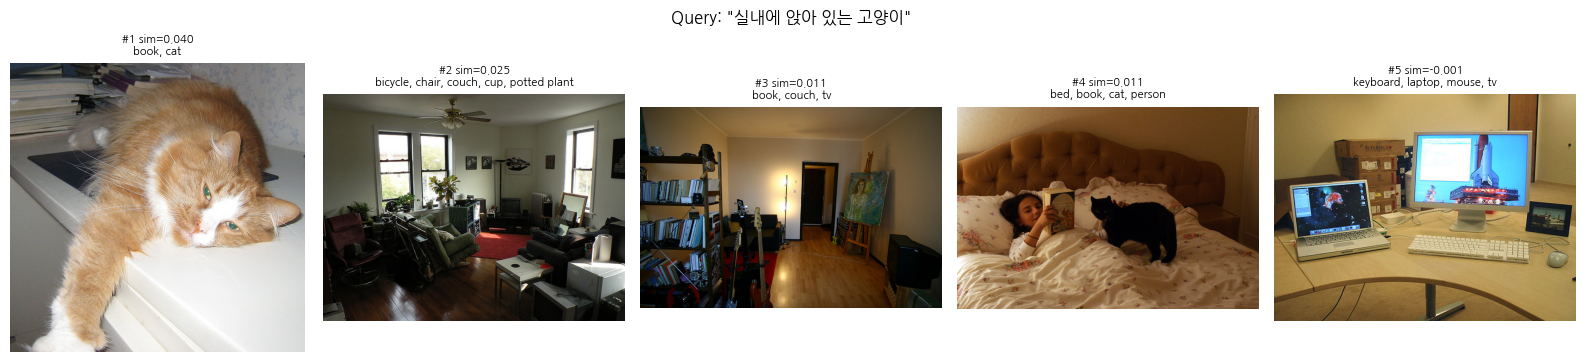


검색 결과:
  [1] id=58111  similarity=0.0400  labels=book, cat
  [2] id=36844  similarity=0.0252  labels=bicycle, chair, couch, cup, potted plant, refrigerator, remote, tv
  [3] id=104666  similarity=0.0110  labels=book, couch, tv
  [4] id=458255  similarity=0.0106  labels=bed, book, cat, person
  [5] id=148620  similarity=-0.0007  labels=keyboard, laptop, mouse, tv
  이미지 1/5 요약 완료
  이미지 2/5 요약 완료
  이미지 3/5 요약 완료
  이미지 4/5 요약 완료
  이미지 5/5 요약 완료

이미지 요약:
이미지 1: 금발 흰 코의 고양이가 책상 위에 누워 눈을 뜨고 있다.
이미지 2: living room에 가구와 식물들이 배치된 편안한 공간입니다.
이미지 3: living room에 기타와 그림, TV가 있는 따뜻한 분위기의 공간입니다.
이미지 4: 침대에 누워서 책을 읽는 소녀와 검은 고양이가 함께 있는 모습.
이미지 5: 사무실 책상에 노트북과 모니터가 놓여 있고 배경에는 상자들이 쌓여 있습니다.

공통점:
이 이미지는 모두 실내 환경을 담고 있으며, 각각 다른 장소에서 일상적인 순간들을 포착하고 있습니다. 고양이와 인간이 함께하는 생활 공간, 그리고 작업용 책상 등 다양한 인테리어가 보이며, 모든 장면은 평온하거나 집중적인 분위기를 자아냅니다. 특히 첫 번째와 네 번째 이미지에서는 동물과 사람의 근접한 관계가 강조되며, 마지막 두 이미지는 인간의 업무나 여유 시간을 나타냅니다. 전체적으로는 주거 공간이나 작업 공간에서의 일상적이고 따뜻한 순간들로 구성되어 있습니다.


In [ ]:
# 한글 쿼리 — OpenCLIP vs SigLIP2 비교 + SigLIP2 Visual RAG
KOREAN_QUERY = "실내에 앉아 있는 고양이"

compare_retrievers(KOREAN_QUERY, top_k=5)  # 검색만 비교 (Qwen 미사용)

result_siglip = visual_rag_siglip2(KOREAN_QUERY, top_k=5)  # 한글 end-to-end 파이프라인

# RTX 3060 : 약 7분 소요

## 7. 정리

이 노트북은 COCO **100장**으로 Visual RAG 파이프라인을 구성했습니다.  
검색(Retriever)은 **두 가지**를 제공하고, 생성(Generator)은 **Qwen3-VL** 하나를 공유합니다.

### 전체 아키텍처

```
                    ┌── OpenCLIP ──► coco_clip_100 ──┐
COCO 100장 ──임베딩──┤                                 ├── Top-k ──► Qwen3-VL ──► 요약 · 공통점
                    └── SigLIP2  ──► coco_siglip2_100 ┘
                              ▲
                         텍스트 쿼리
                    (영어: OpenCLIP / 한글: SigLIP2)
```

### 섹션별 역할

| 섹션 | 구성 요소 | 역할 |
|------|-----------|------|
| 1 | COCO val2017 | 학습용 이미지 100장 준비 |
| 2~3 | OpenCLIP + ChromaDB | 영어 쿼리 기반 이미지 검색 |
| 4 | Qwen3-VL-4B | 검색 이미지 요약 및 공통점 분석 |
| 5 | `visual_rag()` | OpenCLIP 검색 + Qwen3-VL 통합 |
| 6 | SigLIP2 So400M | 한글·다국어 쿼리 검색 (`visual_rag_siglip2()`) |

### Retriever vs Generator

- **Retriever (OpenCLIP / SigLIP2 + ChromaDB)**: 가볍고 빠름. 100장 규모에서 수 초 이내 검색.
  - `visual_rag()` — 영어 쿼리에 적합
  - `visual_rag_siglip2()` — **한글 쿼리에 적합**
- **Generator (Qwen3-VL)**: VRAM을 많이 쓰지만 정밀한 시각 이해. Top-k(기본 5장)만 처리.

### 주요 함수

| 함수 | 설명 |
|------|------|
| `search_images()` | OpenCLIP 텍스트 검색 |
| `search_images_siglip2()` | SigLIP2 텍스트 검색 |
| `summarize_images()` | 이미지별 한 문장 요약 |
| `analyze_commonality()` | 검색 이미지 공통점 분석 |
| `compare_retrievers()` | OpenCLIP vs SigLIP2 결과 비교 |
| `visual_rag_siglip2()` | 한글 Visual RAG end-to-end |

### 확장 아이디어

- 이미지 수 확대(1,000장+) 및 ChromaDB HNSW 파라미터 튜닝
- Qwen3-VL로 한글 캡션 생성 후 하이브리드(벡터 + 메타데이터) 검색
- 메타데이터 필터: `where={"labels": {"$contains": "cat"}}`
- Qwen3-VL 2B로 저사양 GPU 추론
- 검색 결과를 컨텍스트로 넣는 멀티턴 Q&A 챗봇 구축

### 핵심 용어 정리 (초보자용)

| 용어 | 쉬운 설명 |
|------|-----------|
| **임베딩** | 이미지·글을 숫자 배열(벡터)로 바꾼 것. 비슷한 내용이면 숫자도 비슷합니다. |
| **벡터 DB** | 임베딩을 저장하고 "가장 비슷한 벡터"를 빠르게 찾는 데이터베이스입니다. |
| **Top-k** | 유사도 상위 k개만 골라내는 것입니다. k가 클수록 다양하지만 Qwen 처리 시간이 늘어납니다. |
| **Retriever** | 질문에 맞는 이미지를 **찾는** 부분 (OpenCLIP 또는 SigLIP2). |
| **Generator** | 찾은 이미지를 **읽고 글로 설명하는** 부분 (Qwen3-VL). |
| **코사인 유사도** | 두 벡터가 같은 방향을 가리키는지 재는 척도. 1에 가까울수록 유사합니다. |
